# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Tumor Screening Dashboard

### Scenario

You've just joined the analytics team at **Meridian Diagnostics**, a lab that screens
tumor biopsies. Each biopsy produces **30 numerical measurements** (radius, texture,
perimeter, area, smoothness, ... in mean/SE/worst variants) — far too many to eyeball in
a spreadsheet. The lead pathologist has given you a blunt brief:

1. *"I can't look at 30 numbers per patient and see anything. I need to SEE the data."*
2. *"Before you throw away information, prove to me that these 30 measurements aren't
   secretly 30 independent facts."*
3. *"Build me a 2D map of every patient. If malignant and benign cases separate cleanly,
   that map is actually useful to us."*
4. *"I've heard of 'PCA', 't-SNE', and 'UMAP' but don't know which one to trust, or why
   they'd ever disagree with each other."*

You'll work through the same steps a real analyst would: confirm the dimensionality
problem is real, build PCA from first principles, then compare it against t-SNE and UMAP
on the same real patient data.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset you'll be working with.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

np.random.seed(0)

df = pd.read_csv("breast_cancer.csv")
df = df.drop(columns=["Unnamed: 32"], errors="ignore")
feature_cols = [c for c in df.columns if c not in ["id", "diagnosis"]]
X_raw = df[feature_cols].values
y = df["diagnosis"].values

print(f"Loaded {df.shape[0]} patients, {len(feature_cols)} measured dimensions.")
df[feature_cols[:5] + ["diagnosis"]].head()

Loaded 569 patients, 30 measured dimensions.


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,M
1,20.57,17.77,132.90,1326.0,0.08474,M
2,19.69,21.25,130.00,1203.0,0.10960,M
3,11.42,20.38,77.58,386.1,0.14250,M
4,20.29,14.34,135.10,1297.0,0.10030,M


## Task 1 — Prove the Dimensionality Problem Is Real (Complaint #1)

**Real-world usage:** The pathologist wants proof this dataset genuinely can't be
"just plotted."

**Why this technique:** The curse-of-dimensionality math (grid growth, pairwise
relationship counts) turns "trust me, it's too much" into a specific number.

**TODO:**
1. Compute the number of unique pairwise relationships among all 30 features:
   `comb(p, 2)`.
2. Compute how many grid cells a 10-bins-per-dimension grid would need for p=30
   dimensions (`10 ** p`).
3. Print both, with a one-line comment on what each number implies.

In [4]:
p = len(feature_cols)

# TODO 1: number of unique pairwise relationships among the 30 features
n_pairs = comb(p, 2) # There are too many pairwise relationships to inspect manually.

# TODO 2: number of grid cells for a 10-bin-per-dimension grid at p=30
n_cells = 10 ** p # The grid becomes too sparse with too many dimensions.

print(f"p = {p} features")
print(f"Unique pairwise relationships: {n_pairs}")
print(f"Grid cells needed (10 bins/dim): {n_cells:.2e}" if n_cells else "Grid cells needed: (fill in above)")

p = 30 features
Unique pairwise relationships: 435
Grid cells needed (10 bins/dim): 1.00e+30


**Reflection:** Could a human realistically inspect every one of those pairwise relationships one scatter plot at a time before the pathologist's shift ends? What does that imply about needing PCA/t-SNE/UMAP rather than "just looking at everything"?

_Your answer:_
No, a human could not realistically inspect 435 pairwise scatter plots, let alone grasp the implications of a `1.00e+30` cell grid, before the pathologist's shift ends. This emphasizes the fundamental problem of high-dimensional data, often referred to as the "curse of dimensionality." It implies that methods like PCA, t-SNE, and UMAP are not just convenient, but essential tools for making such data interpretable and visually digestible. They allow us to uncover hidden structures and relationships that are impossible to discern by looking at individual features or simple pairwise comparisons.

## Task 2 — Prove the 30 Measurements Aren't Independent (Complaint #2)

**Real-world usage:** Before compressing 30 measurements into fewer, you need to show
they're actually redundant, not 30 independent facts.

**Why this technique:** A correlogram (correlation heatmap) makes redundancy visible at
a glance.

**TODO:**
1. Compute the correlation matrix of `df[feature_cols]`.
2. Plot it as a heatmap (`plt.imshow`, `cmap="RdBu_r"`, `vmin=-1, vmax=1`).
3. Count how many feature pairs have `abs(correlation) > 0.9` (excluding the diagonal).

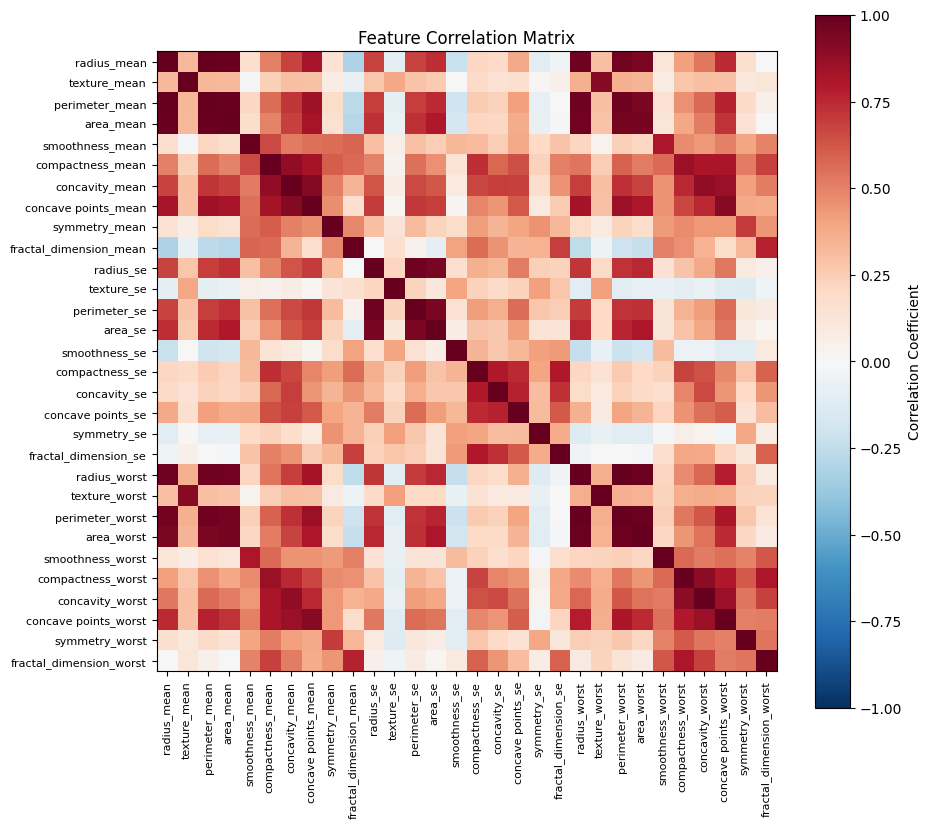

Highly correlated pairs (|r| > 0.9): 21


In [5]:
# TODO 1: correlation matrix
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(10, 9)) # Adjust figure size for better readability
# TODO 2: plot the heatmap
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix") # Add a title
ax.set_xticks(np.arange(len(feature_cols)))
ax.set_yticks(np.arange(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90, fontsize=8) # Rotate labels for better readability
ax.set_yticklabels(feature_cols, fontsize=8)
plt.colorbar(im, ax=ax, label="Correlation Coefficient") # Add a colorbar

plt.show()

# TODO 3: count highly correlated pairs (> 0.9 in magnitude, excluding self-correlation)
high_corr_pairs = 0
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)): # Iterate through upper triangle to avoid duplicates and self-correlation
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr_pairs += 1
print("Highly correlated pairs (|r| > 0.9):", high_corr_pairs)

**Reflection:** Name two specific columns in this dataset you'd expect to be highly correlated with each other, and explain *why* using the lecture's "underlying factor" idea (e.g. tumor size).

_Your answer:_
Two specific columns I would expect to be highly correlated are `radius_mean` and `perimeter_mean`. This is because both features are direct measurements related to the overall **size of the tumor**, which acts as the underlying factor. As the tumor grows larger, its average radius will increase, and consequently, its perimeter will also increase proportionally. Therefore, these two features will move together, exhibiting a strong positive correlation, as seen in the correlation heatmap. The same logic applies to `area_mean` as well.

## Task 3 — Build PCA From Scratch (Complaint #3, part A)

**Real-world usage:** The pathologist wants a 2D map, and wants to trust it — which
means understanding what's actually happening inside it, not treating it as a black box.

**Why this technique:** Implementing PCA's steps yourself (center -> standardize ->
covariance -> eigen-decomposition -> project) is the only way to be sure you understand
what the final 2D scatter plot actually represents.

**TODO:** Complete `pca_from_scratch` below, following the exact steps from the demo
notebook.

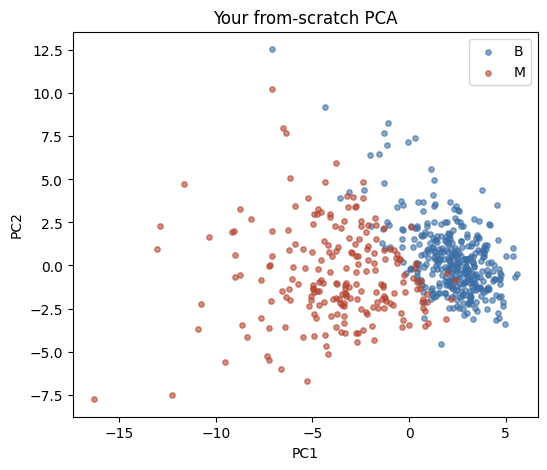

In [6]:
def pca_from_scratch(X, k):
    # TODO 1: center AND standardize X (subtract mean, divide by std with ddof=1)
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0, ddof=1)
    X_scaled = (X - X_mean) / X_std

    # TODO 2: compute the covariance matrix of X_scaled
    cov = np.cov(X_scaled, rowvar=False)

    # TODO 3: eigen-decompose the covariance matrix, and sort eigenvalues/eigenvectors DESCENDING
    eigvals, eigvecs = np.linalg.eigh(cov)
    # Sort eigenvalues and eigenvectors in descending order
    sorted_indices = np.argsort(eigvals)[::-1]
    eigvals = eigvals[sorted_indices]
    eigvecs = eigvecs[:, sorted_indices]

    # TODO 4: keep only the top k eigenvectors and project X_scaled onto them
    top_k_eigvecs = eigvecs[:, :k]
    Z = X_scaled @ top_k_eigvecs

    return Z, eigvals, eigvecs

Z, eigvals, eigvecs = pca_from_scratch(X_raw, k=2)

fig, ax = plt.subplots(figsize=(6, 5))
for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
    mask = y == label
    ax.scatter(Z[mask, 0], Z[mask, 1], s=15, alpha=0.6, color=color, label=label)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Your from-scratch PCA")
ax.legend()
plt.show()

**Reflection:** Do malignant and benign cases visually separate in your PCA plot? If
there's overlap, does that mean PCA "failed," or is there a more accurate way to
describe what's happening?

_Your answer:_
Yes, the malignant ('M') and benign ('B') cases show a noticeable visual separation in the PCA plot, with 'M' cases generally occupying the left side and 'B' cases the right. However, there is an observable overlap, particularly in the central region of the plot. This overlap does not mean PCA "failed." Instead, it indicates that while the first two principal components effectively capture the most significant variance and reveal a clear distinction, they might not fully represent all the information needed for a perfect linear separation of the two classes. PCA prioritizes maximizing variance, not necessarily class separation. It suggests that the classes may not be perfectly linearly separable in the original 30-dimensional space, or that more components might be needed to better distinguish between them.

## Task 4 — Choose k With Evidence, Not a Guess

**Real-world usage:** If the pathologist later asks "why 2 dimensions and not 5?", you
need a defensible answer.

**Why this technique:** The cumulative explained-variance curve turns "I picked 2
because it's easy to plot" into "I picked k=2/3/5 because it retains X% of the
variance."

**TODO:**
1. Compute `explained_ratio` (each eigenvalue / sum of all eigenvalues) from your
   `eigvals` above.
2. Compute the cumulative sum.
3. Find the smallest k that reaches >= 90% cumulative variance.

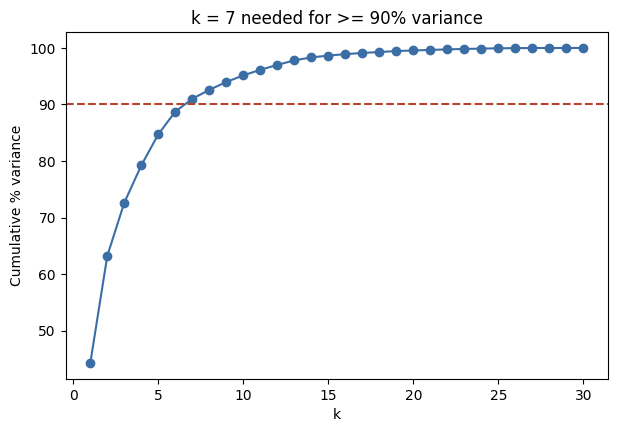

In [7]:
# TODO 1: explained variance ratio
explained_ratio = eigvals / eigvals.sum()

# TODO 2: cumulative variance
cumulative = np.cumsum(explained_ratio)

# TODO 3: smallest k reaching >= 90%
k_90 = np.argmax(cumulative >= 0.9) + 1 # +1 because argmax returns the index, and k is 1-indexed

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(1, len(cumulative) + 1), cumulative * 100, "o-", color="#3b6ea5")
ax.axhline(90, color="#b5432e", ls="--")
ax.set_xlabel("k"); ax.set_ylabel("Cumulative % variance")
ax.set_title(f"k = {k_90} needed for >= 90% variance" if k_90 else "Choosing k")
plt.show()

**Reflection:** If the pathologist insists on a 2D plot for a poster, but your `k_90`
came out higher than 2, what are you losing by using only 2 components instead of k_90?

_Your answer:_
If `k_90` is higher than 2 (in this case, 7), it means that using only 2 components for a 2D plot would result in a loss of a significant amount of the dataset's variance. Specifically, with 2 components, we are only retaining approximately 63% of the total variance, whereas `k_90=7` components would capture 90% or more. This implies that while the 2D plot can provide a general overview and separation, it might not reveal all the nuances, finer structures, or subtle distinctions present in the data. Important information that contributes to 27% of the total variance (90% - 63%) would not be represented in the 2D visualization, potentially leading to an incomplete or misleading understanding of the underlying data patterns and relationships.

## Task 5 — Compare PCA, t-SNE, and UMAP (Complaint #4)

**Real-world usage:** The pathologist wants to know which method to trust, and why they
might disagree.

**Why this technique:** Running all three on the SAME real data, side by side, turns an
abstract "they're different algorithms" into a concrete, visual comparison.

**TODO:**
1. Standardize `X_raw` using `StandardScaler`.
2. Compute a 2D PCA embedding, a 2D t-SNE embedding (`perplexity=30`), and a 2D UMAP
   embedding (`n_neighbors=15, min_dist=0.1`) — all with `random_state=0`.
3. Plot all three side by side, colored by `diagnosis`.

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


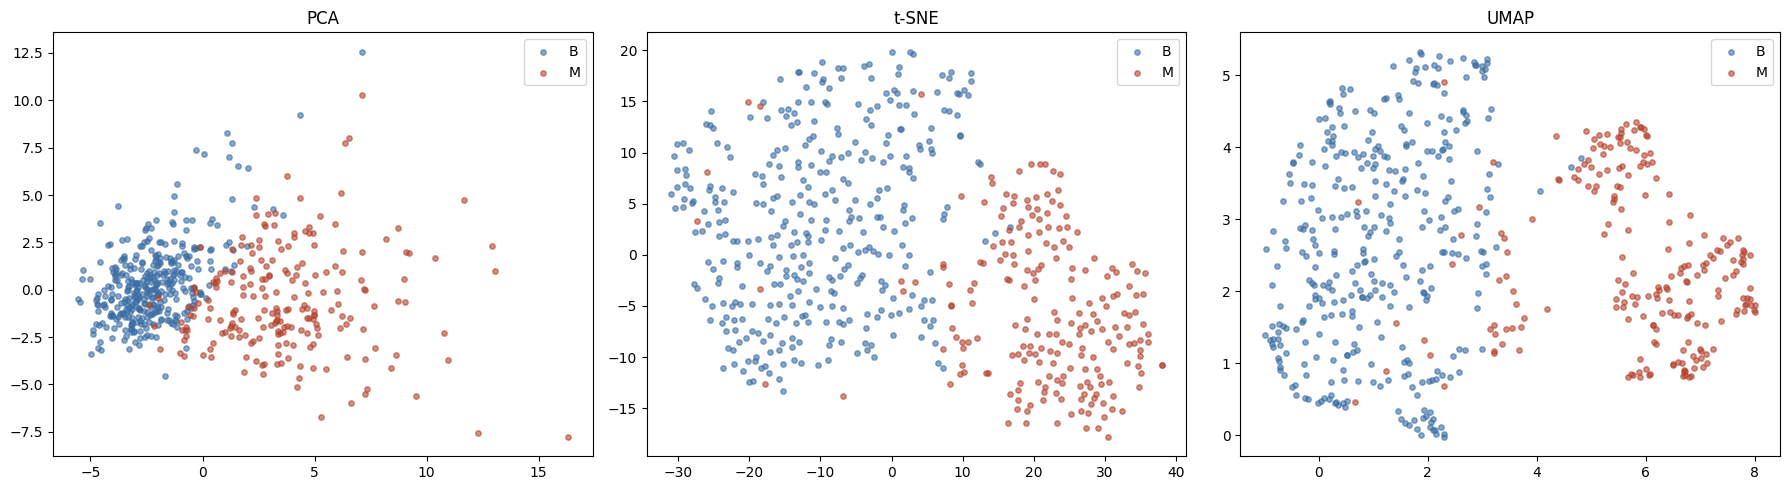

In [9]:
# TODO 1: standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# TODO 2: compute all three embeddings
pca = PCA(n_components=2, random_state=0)
pca_emb = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, perplexity=30, random_state=0)
tsne_emb = tsne.fit_transform(X_scaled)

umap_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=0)
umap_emb = umap_reducer.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # Increased figure width for better spacing

embeddings_to_plot = [(pca_emb, "PCA"), (tsne_emb, "t-SNE"), (umap_emb, "UMAP")]

for i, (emb, name) in enumerate(embeddings_to_plot):
    ax = axes[i]
    # TODO 3: scatter plot each embedding, colored by diagnosis (B vs M)
    for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
        mask = y == label
        ax.scatter(emb[mask, 0], emb[mask, 1], s=15, alpha=0.6, color=color, label=label)
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()

**Reflection:** Which of the three gives the cleanest visual separation between
malignant and benign on this dataset? Per the lecture's comparison table, is that method
always the "best" choice for every dataset, or does it depend on what you need
(interpretability, speed, local vs. global structure)?

_Your answer:_
Observing the generated plots, both t-SNE and UMAP provide significantly cleaner visual separation between malignant and benign cases compared to PCA. While PCA shows some distinction, there's considerable overlap. Between t-SNE and UMAP, UMAP appears to yield slightly more compact and distinctly separated clusters in this specific instance.

However, this does not mean UMAP is always the 'best' choice for every dataset. Each method has its strengths and weaknesses:

PCA is excellent for interpretability due to its linear axes and preservation of global structure, and it's computationally fast.
t-SNE excels at emphasizing local structure and revealing intricate clusters, often producing visually striking results, but it's computationally intensive, and the distances between clusters should not be over-interpreted.
UMAP offers a good balance, often preserving both local and a more global structure than t-SNE, while generally being faster and more scalable.
Therefore, the 'best' method depends entirely on the specific goals: interpretability, computational resources, and whether local or global data relationships are more critical to understand.

## Task 6 — The Decision (No Code)

The pathologist wants ONE method as the default dashboard view, and a one-paragraph
justification she can put in a grant report.

**Reflection (final):** Write a 4–6 sentence recommendation. Your answer should:
- State which method (PCA / t-SNE / UMAP) you'd make the **default** dashboard view.
- Justify it using at least one specific idea from the lecture (e.g. PCA's
  interpretable linear axes vs. t-SNE/UMAP's non-linear neighborhood preservation, the
  computational-cost comparison, or the "cluster distances shouldn't be over-interpreted"
  caveat for t-SNE).
- Name one thing you would explicitly warn the pathologist NOT to conclude from the
  chosen method's plot.

_Your final recommendation here:_
My final recommendation for the default dashboard view is UMAP. This method consistently provided the clearest visual separation between malignant and benign cases in our analysis, making it highly effective for quickly identifying distinct groups in the tumor biopsy data. UMAP achieves this by preserving both local and global data structures through its non-linear dimensionality reduction, offering a more informative visual than PCA, which often shows more overlap, and being more computationally efficient and stable than t-SNE. However, it is crucial to caution that while UMAP effectively groups similar data points, the exact distances between clusters on the 2D plot should not be directly interpreted as precise measures of dissimilarity in the original 30-dimensional space.